## Analisi traffico

In [15]:
%reload_ext autoreload
%autoreload 2

In [16]:
import pandas as pd

### Import data    

In [17]:
data = pd.read_csv('weekly_traffic_by_category.csv')

data.head()

,week_name,pagePath,sessions,engagedSessions,screenPageViews,category
0,25011,/419840/latest-news/alice-in-borderland-3-e-vi...,1253,736,1256,News
1,25011,/389791/latest-news/anticipazioni/suburraetern...,259,150,259,Anticipazioni
2,25011,/420566/taxidrivers-magazine/acab-la-serie-dal...,162,101,171,Speciali e Magazine
3,25011,/279976/review/approfondimenti/venti-film-sull...,142,70,150,Recensioni
4,25011,/419995/magazine-2/golden-globes-2025-i-vincit...,141,75,155,Speciali e Magazine


### Enrich data

In [18]:
# Enrich data
data['engagement_rate'] = data['engagedSessions'] / data['sessions']

In [19]:
data.describe()

,week_name,sessions,engagedSessions,screenPageViews,engagement_rate
count,267832.000000,267832.000000,267832.000000,267832.000000,267832.000000
mean,25327.076746,4.179904,2.553967,4.327224,0.626963
std,419.758592,18.403993,11.058057,18.920903,0.418828
min,25011.000000,1.000000,0.000000,0.000000,0.000000
25%,25062.000000,1.000000,0.000000,1.000000,0.000000
50%,25101.000000,1.000000,1.000000,1.000000,0.800000
75%,26011.000000,3.000000,2.000000,3.000000,1.000000
max,26044.000000,1594.000000,996.000000,1620.000000,1.000000


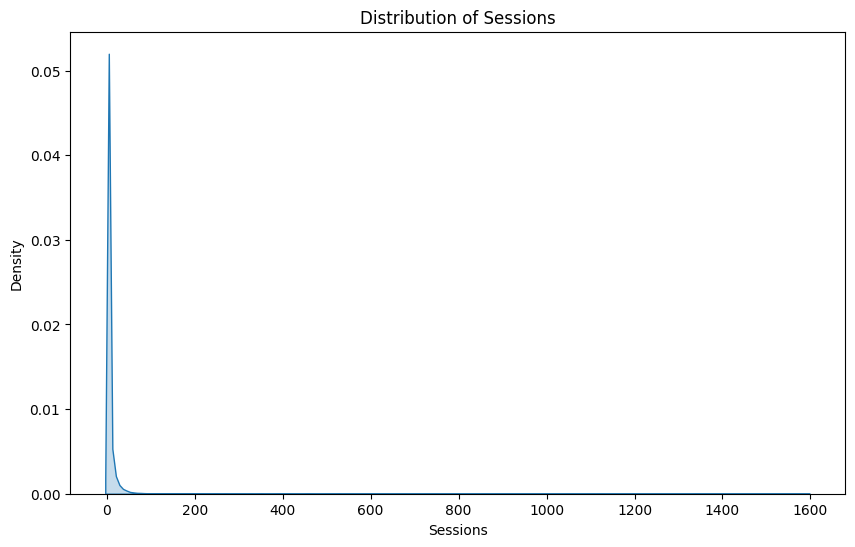

In [20]:
# Kde plot of sessions
import seaborn as sns
import matplotlib.pyplot as plt
plt.figure(figsize=(10, 6))
sns.kdeplot(data=data, x='sessions', fill=True)
plt.title('Distribution of Sessions')
plt.xlabel('Sessions')
plt.ylabel('Density')
plt.show()

In [21]:
threshold = 0.9
percentile_at_threshold = data['sessions'].quantile(threshold)
print(f'percentile of sessions at threshold {threshold}: {percentile_at_threshold}')

percentile of sessions at threshold 0.9: 7.0


Il 57% degli articoli riceve meno di 1 visualizzazione nella settimana (concatenando le settimane)

Per ogni settimana, è stato considerato solo il set di articoli che ha generato un numero minimo di sessioni, con soglia inferiore corrispondente al 90-esimo percentile della distribuzione delle sessioni. In questo modo ci assicuriamo che gli articoli inclusi nel set di analisi di ogni settimana includa in maggioranza articoli pubblicati in quella stessa settimana [TODO]. Resta comunque un'ipotesi da confermare.    

### Process data by week

In [22]:
def _filter_top_sessions(data, threshold=0.9):
    percentile_at_threshold = data['sessions'].quantile(threshold)
    print(f'percentile of sessions at threshold {threshold}: {percentile_at_threshold}')
    filtered_data = data[data['sessions'] > percentile_at_threshold]
    return filtered_data
    
def _process_week(data, week):
    threshold = 0.9
    week_data = data[data['week_name'] == week]
    filtered_data = _filter_top_sessions(week_data, threshold)
    return filtered_data

def process_all_weeks(data):
    weeks = data['week_name'].unique()
    all_processed_data = pd.DataFrame()
    for week in weeks:
        filtered_data = _process_week(data, week)
        all_processed_data = pd.concat([all_processed_data, filtered_data], ignore_index=True)
    return all_processed_data

processed_data = process_all_weeks(data)


percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 8.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 8.0
percentile of sessions at threshold 0.9: 6.0
percentile of sessions at threshold 0.9: 8.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 8.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 6.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 6.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile of sessions at threshold 0.9: 7.0
percentile

In [23]:
# Compute count of rows in processed_data for each week
n_articles_by_month = processed_data.groupby('week_name').size()

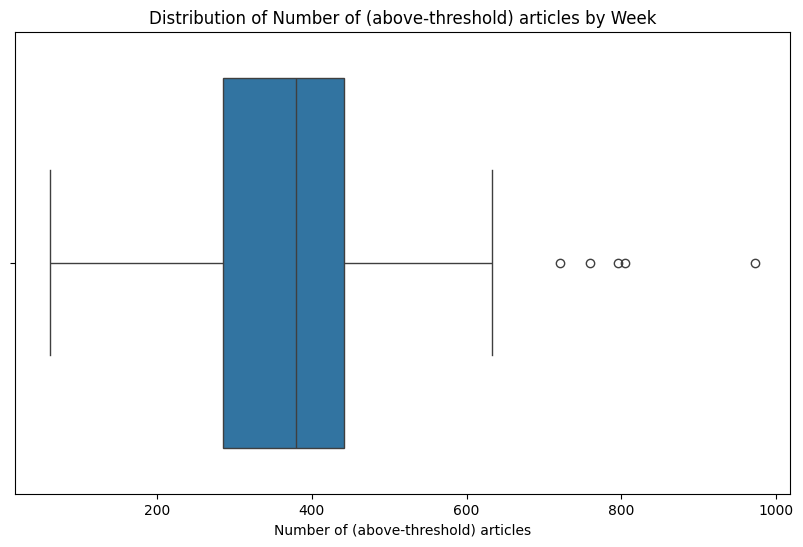

In [24]:
# Boxplot of n_articles_by_month
plt.figure(figsize=(10, 6))
sns.boxplot(x=n_articles_by_month)
plt.title('Distribution of Number of (above-threshold) articles by Week')
plt.xlabel('Number of (above-threshold) articles')
plt.show()

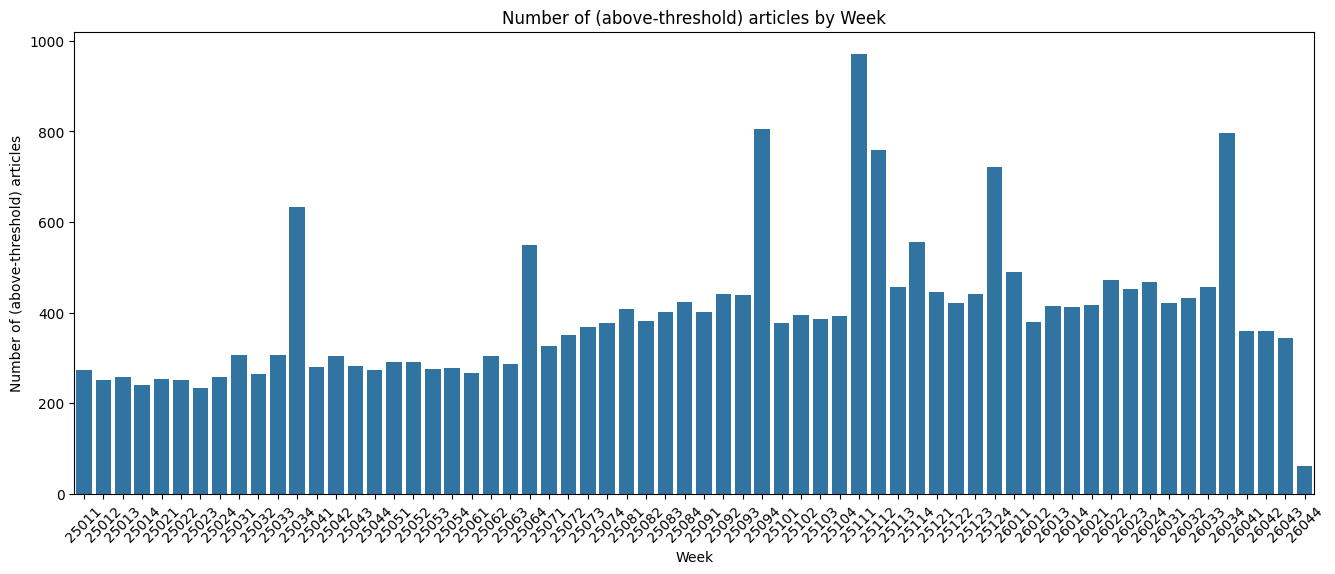

In [25]:
# Lollipop chart of n_articles_by_month
plt.figure(figsize=(16, 6))
sns.barplot(x=n_articles_by_month.index, y=n_articles_by_month.values)
plt.title('Number of (above-threshold) articles by Week')
plt.xlabel('Week')
plt.ylabel('Number of (above-threshold) articles')
plt.xticks(rotation=45)
plt.show()

Il numero di articoli sopra il 90-esimo percentile aumenta nel tempo, segno di un trend al rialzo.

Nel tempo è aumentato il numero di articoli che ricevono un numero di visualizzazioni rilevante.  
Le disparità restano comunque rilevanti [TODO] Articoli nuovi che ricevono poche visualizzazioni].

Siamo ancora al di sopra del valore soglia della prima settimana di gennaio 25 [quale margine %?]


In [26]:
 
### Visualizzazioni ricevuto dei nuovi articoli nella settimana. 

### Scraping publication date

Per ogni articolo in `processed_data` viene recuperata la data di pubblicazione via scraping da taxidrivers.it.  
Lo scraping viene eseguito solo sugli URL filtrati (top 10% per sessioni), in chunk da 20 URL con delay di 3s tra articolo e 10s tra chunk.

In [27]:
import sys
from pathlib import Path

ROOT = Path().resolve().parents[2]
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from reports.ad_hoc_reports.analisi_traffico.weekly_traffic_by_category import scrape_publication_dates

In [28]:
from reports.ad_hoc_reports.analisi_traffico.weekly_traffic_by_category import load_scrape_cache

cache_before = load_scrape_cache()
print(f"Cache attuale: {len(cache_before)} URL già scrapati\n")

weeks = processed_data["week_name"].unique().tolist()
print(f"Settimane totali in processed_data: {len(weeks)}\n")

all_scraped = []

for i, week in enumerate(weeks, start=1):
    week_subset = processed_data[processed_data["week_name"] == week].copy()
    print(f"[{i}/{len(weeks)}] Settimana {week}: {len(week_subset['pagePath'].unique())} URL unici")
    scraped = scrape_publication_dates(week_subset)
    all_scraped.append(scraped)

scraped_subset = pd.concat(all_scraped, ignore_index=True)

cache_after = load_scrape_cache()
print(f"\nCache: {len(cache_before)} → {len(cache_after)} (+{len(cache_after) - len(cache_before)} nuovi)")
print(f"Scraping completato: {len(scraped_subset)} righe, {scraped_subset['publication_date'].notna().sum()} date recuperate")
# Save scraped_subset to CSV
scraped_subset.to_csv("scraped_publication_dates.csv", index=False)

Cache attuale: 4726 URL già scrapati

Settimane totali in processed_data: 64

[1/64] Settimana 25011: 273 URL unici

Scraping publication_date: 273 URL unici → 273 da cache, 0 da scrapare (chunk=20, delay=1s, inter-chunk=60s)
[2/64] Settimana 25012: 252 URL unici

Scraping publication_date: 252 URL unici → 252 da cache, 0 da scrapare (chunk=20, delay=1s, inter-chunk=60s)
[3/64] Settimana 25013: 258 URL unici

Scraping publication_date: 258 URL unici → 258 da cache, 0 da scrapare (chunk=20, delay=1s, inter-chunk=60s)
[4/64] Settimana 25014: 239 URL unici

Scraping publication_date: 239 URL unici → 239 da cache, 0 da scrapare (chunk=20, delay=1s, inter-chunk=60s)
[5/64] Settimana 25021: 254 URL unici

Scraping publication_date: 254 URL unici → 254 da cache, 0 da scrapare (chunk=20, delay=1s, inter-chunk=60s)
[6/64] Settimana 25022: 251 URL unici

Scraping publication_date: 251 URL unici → 251 da cache, 0 da scrapare (chunk=20, delay=1s, inter-chunk=60s)
[7/64] Settimana 25023: 234 URL un

KeyboardInterrupt: 